In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from IPython import get_ipython
import warnings
warnings.filterwarnings("ignore")


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv


In [2]:
df=pd.read_csv("/kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [4]:
df.sample(7)

,N,P,K,temperature,humidity,ph,rainfall,label
1522,2,143,196,22.712713,90.452617,5.669489,109.885260,apple
2182,103,33,33,26.717174,50.501485,7.131436,126.807398,coffee
1500,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
787,44,55,25,29.632105,65.913600,7.421608,71.163320,blackgram
1047,90,86,52,25.850370,81.955805,5.793260,119.085617,banana
1054,95,75,45,28.983334,82.959582,5.829899,109.022564,banana
222,31,78,76,17.572121,14.999275,8.519976,89.310507,chickpea


In [5]:
df.shape

(2200, 8)

In [6]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [9]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [10]:
df.nunique()

N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64

In [11]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [12]:
df['label'].value_counts()

rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: label, dtype: int64

In [13]:
crop_summary = pd.pivot_table(df,index=['label'],aggfunc='mean')
crop_summary

,K,N,P,humidity,ph,rainfall,temperature
label,,,,,,,
apple,199.89,20.80,134.22,92.333383,5.929663,112.654779,22.630942
banana,50.05,100.23,82.01,80.358123,5.983893,104.626980,27.376798
blackgram,19.24,40.02,67.47,65.118426,7.133952,67.884151,29.973340
chickpea,79.92,40.09,67.79,16.860439,7.336957,80.058977,18.872847
coconut,30.59,21.98,16.93,94.844272,5.976562,175.686646,27.409892
coffee,29.94,101.20,28.74,58.869846,6.790308,158.066295,25.540477
cotton,19.56,117.77,46.24,79.843474,6.912675,80.398043,23.988958
grapes,200.11,23.18,132.53,81.875228,6.025937,69.611829,23.849575
jute,39.99,78.40,46.86,79.639864,6.732778,174.792798,24.958376


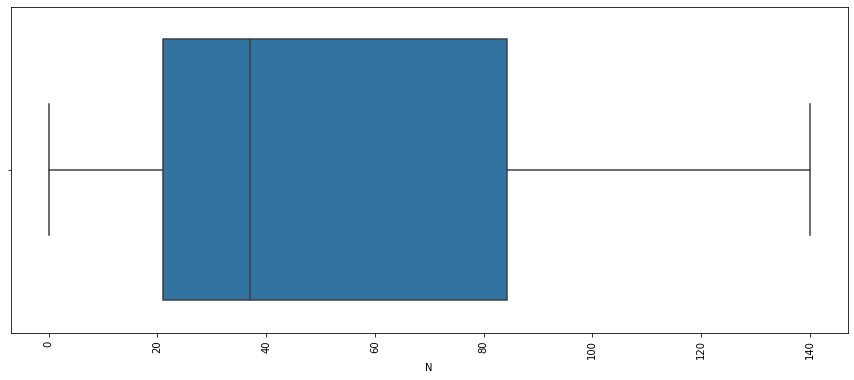

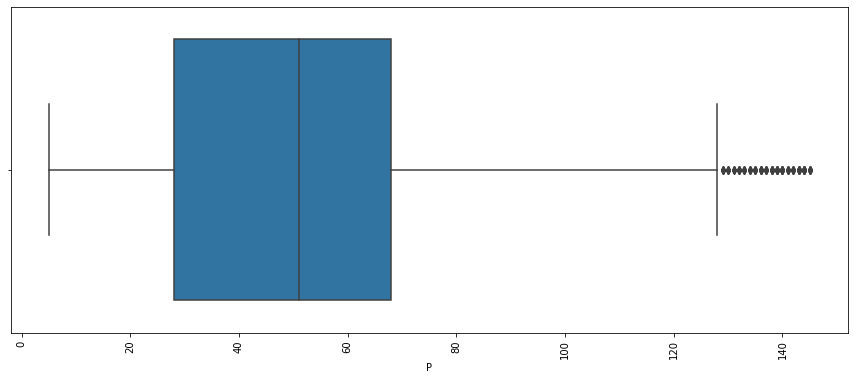

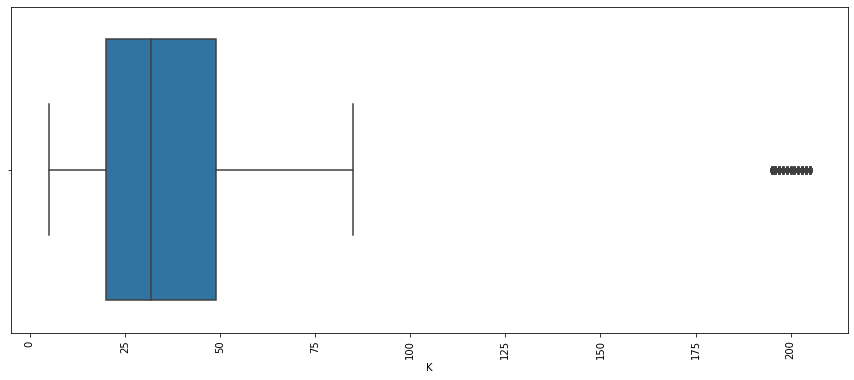

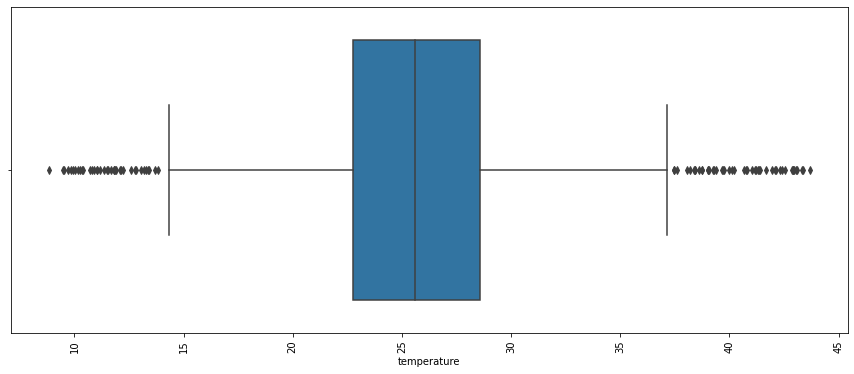

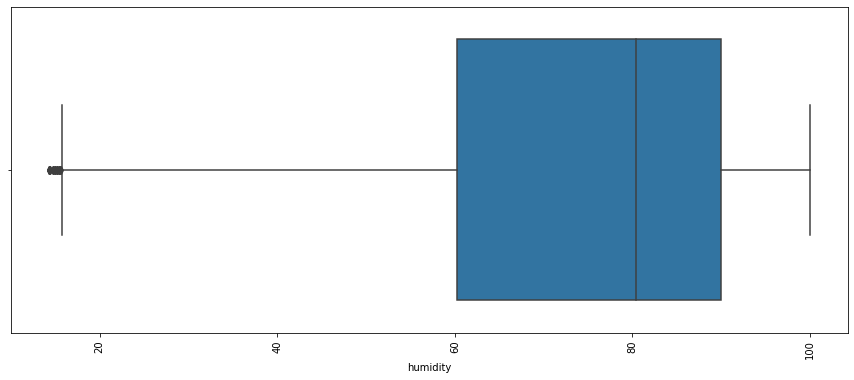

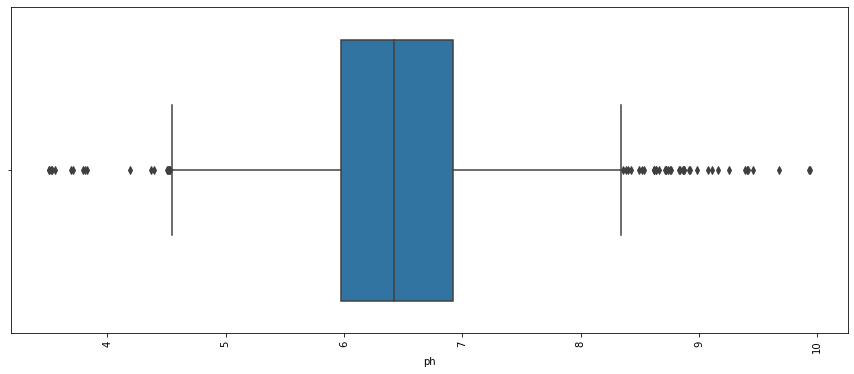

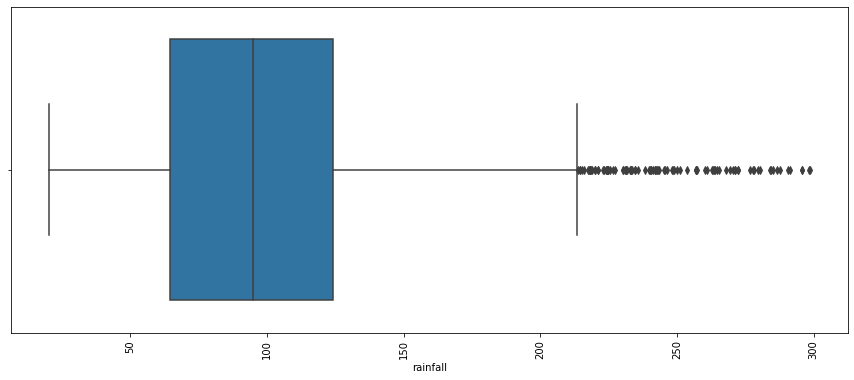

In [14]:
df1 = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
for i in df1.columns:
    plt.figure(figsize=(15,6))
    sns.boxplot(df1[i])
    plt.xticks(rotation = 90)
    plt.show()

In [15]:
crop_summary_new = crop_summary.reset_index()
crop_summary_new

,label,K,N,P,humidity,ph,rainfall,temperature
0,apple,199.89,20.80,134.22,92.333383,5.929663,112.654779,22.630942
1,banana,50.05,100.23,82.01,80.358123,5.983893,104.626980,27.376798
2,blackgram,19.24,40.02,67.47,65.118426,7.133952,67.884151,29.973340
3,chickpea,79.92,40.09,67.79,16.860439,7.336957,80.058977,18.872847
4,coconut,30.59,21.98,16.93,94.844272,5.976562,175.686646,27.409892
5,coffee,29.94,101.20,28.74,58.869846,6.790308,158.066295,25.540477
6,cotton,19.56,117.77,46.24,79.843474,6.912675,80.398043,23.988958
7,grapes,200.11,23.18,132.53,81.875228,6.025937,69.611829,23.849575
8,jute,39.99,78.40,46.86,79.639864,6.732778,174.792798,24.958376
9,kidneybeans,20.05,20.75,67.54,21.605357,5.749411,105.919778,20.115085


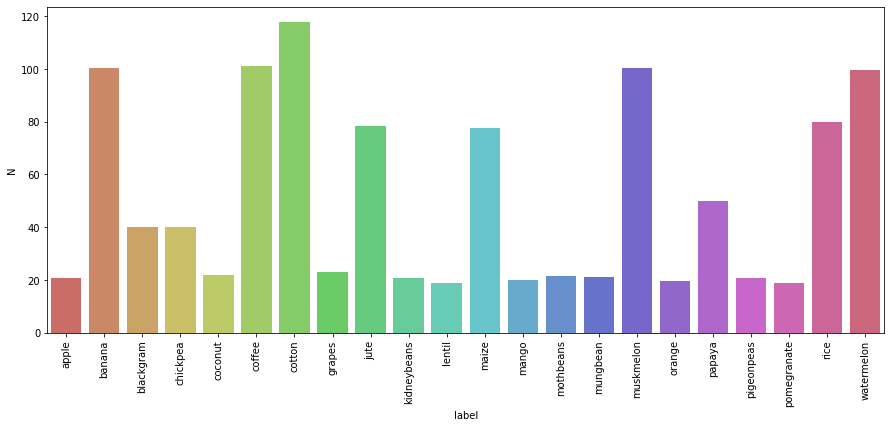

In [16]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'N', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

In [17]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [18]:
fig1 = px.bar(crop_summary_new, x='label', y='N')
fig1.show()

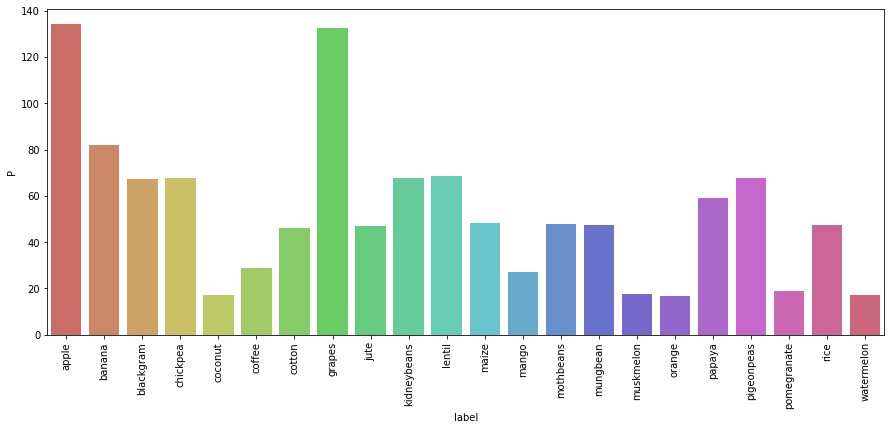

In [19]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'P', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

In [20]:
fig2 = px.bar(crop_summary_new, x='label', y='P')
fig2.show()

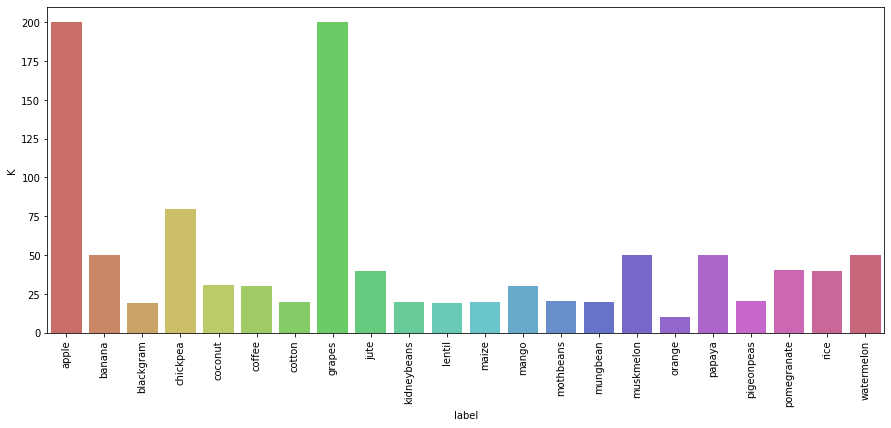

In [21]:
plt.figure(figsize=(15,6))
sns.barplot(y = 'K', x = 'label', data=crop_summary_new, palette = 'hls')
plt.xticks(rotation = 90)
plt.show()

In [22]:
df.corr()

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


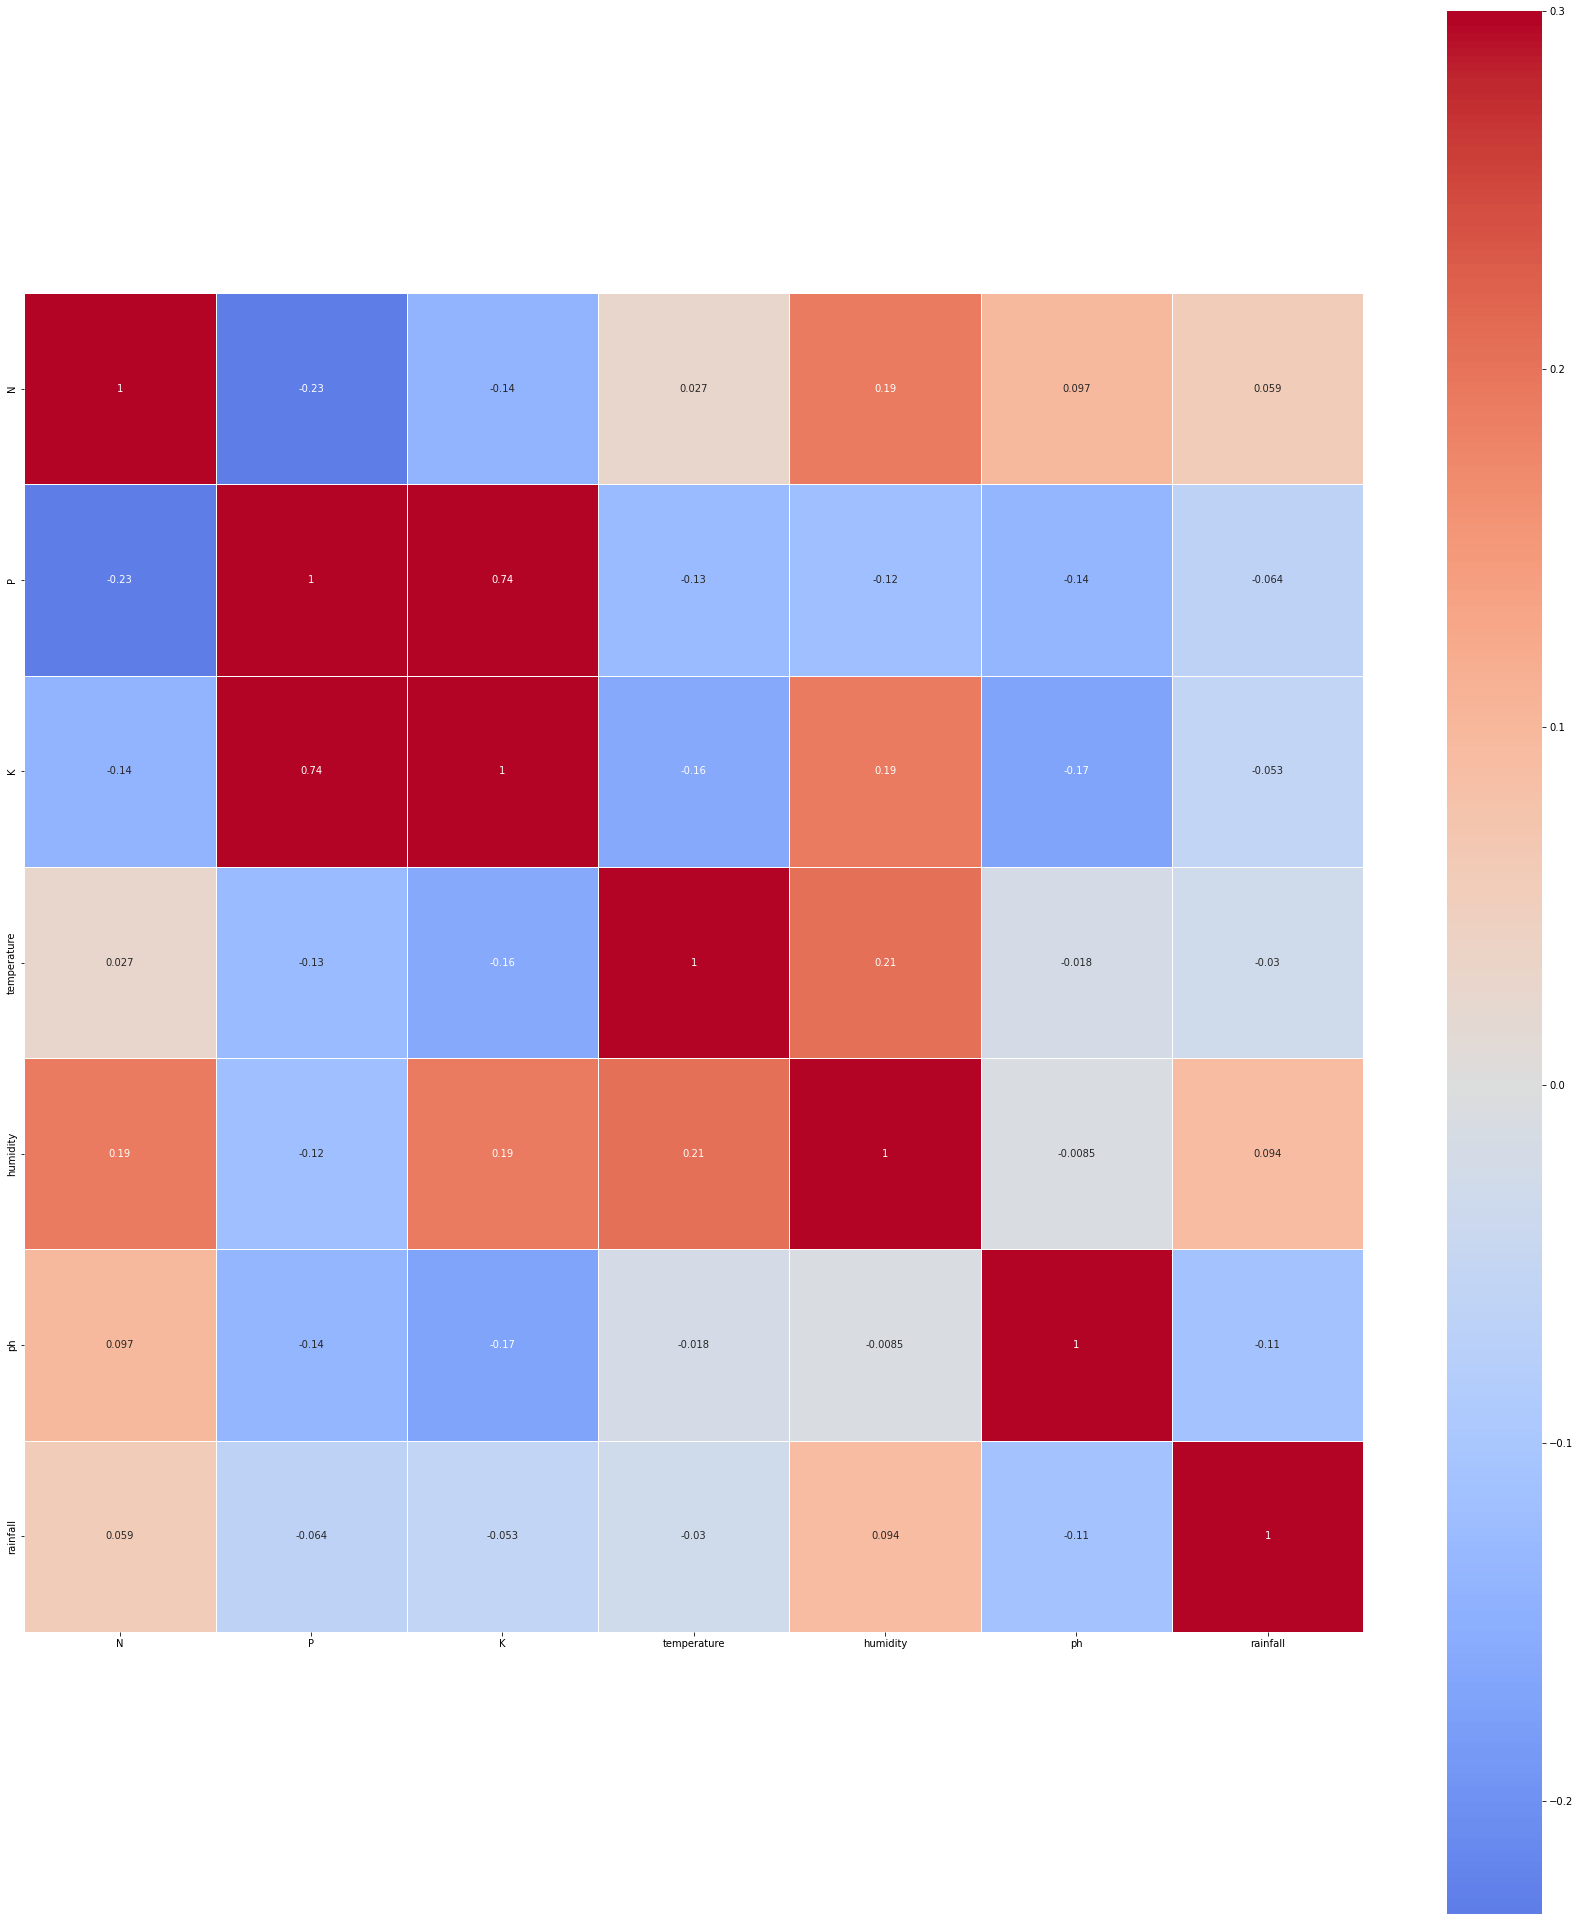

In [23]:
plt.figure(figsize=(30,35))
sns.heatmap(df.corr(),  cmap='coolwarm', vmax=.3, center=0,
            square=True, linewidths=.5,annot=True)
plt.show()

In [24]:
import networkx as nx
corr=df.corr()
indices = corr.index.values
cor_matrix = np.asmatrix(corr)
G = nx.from_numpy_matrix(cor_matrix)
G = nx.relabel_nodes(G,lambda x: indices[x])
G.edges(data=True)

EdgeDataView([('N', 'N', {'weight': 1.0}), ('N', 'P', {'weight': -0.23145957738457262}), ('N', 'K', {'weight': -0.14051183844915763}), ('N', 'temperature', {'weight': 0.026503796219081235}), ('N', 'humidity', {'weight': 0.19068837919787315}), ('N', 'ph', {'weight': 0.09668284622242848}), ('N', 'rainfall', {'weight': 0.05902022369254324}), ('P', 'P', {'weight': 1.0}), ('P', 'K', {'weight': 0.736232217244661}), ('P', 'temperature', {'weight': -0.12754112864533876}), ('P', 'humidity', {'weight': -0.11873411647954892}), ('P', 'ph', {'weight': -0.13801889348863647}), ('P', 'rainfall', {'weight': -0.063839051330259}), ('K', 'K', {'weight': 1.0}), ('K', 'temperature', {'weight': -0.16038713278089597}), ('K', 'humidity', {'weight': 0.1908588608364631}), ('K', 'ph', {'weight': -0.16950309817325426}), ('K', 'rainfall', {'weight': -0.05346135449256889}), ('temperature', 'temperature', {'weight': 1.0}), ('temperature', 'humidity', {'weight': 0.2053196766307067}), ('temperature', 'ph', {'weight': -

In [25]:
def corr_network(G, corr_direction, min_correlation):
    H = G.copy()

    for s1, s2, weight in G.edges(data=True):       
        if corr_direction == "positive":
            if weight["weight"] < min_correlation or s1==s2:
                H.remove_edge(s1, s2)
        else:
            if weight["weight"] > min_correlation or s1==s2:
                H.remove_edge(s1, s2)
                
    edges,weights = zip(*nx.get_edge_attributes(H,'weight').items())

    weights = tuple([(1+abs(x))**2 for x in weights])
   
    d = dict(nx.degree(H))
    nodelist=d.keys()
    node_sizes=d.values()
    
    positions=nx.circular_layout(H)
    
    plt.figure(figsize=(15,15))

    nx.draw_networkx_nodes(H,positions,node_color='#d100d1',nodelist=nodelist,
                       node_size=tuple([x**3 for x in node_sizes]),alpha=0.8)

    nx.draw_networkx_labels(H, positions, font_size=14)

    if corr_direction == "positive":
        edge_colour = plt.cm.summer 
    else:
        edge_colour = plt.cm.autumn
        
    nx.draw_networkx_edges(H, positions, edgelist=edges,style='solid',
                          width=weights, edge_color = weights, edge_cmap = edge_colour,
                          edge_vmin = min(weights), edge_vmax=max(weights))
    plt.axis('off')
    plt.show() 

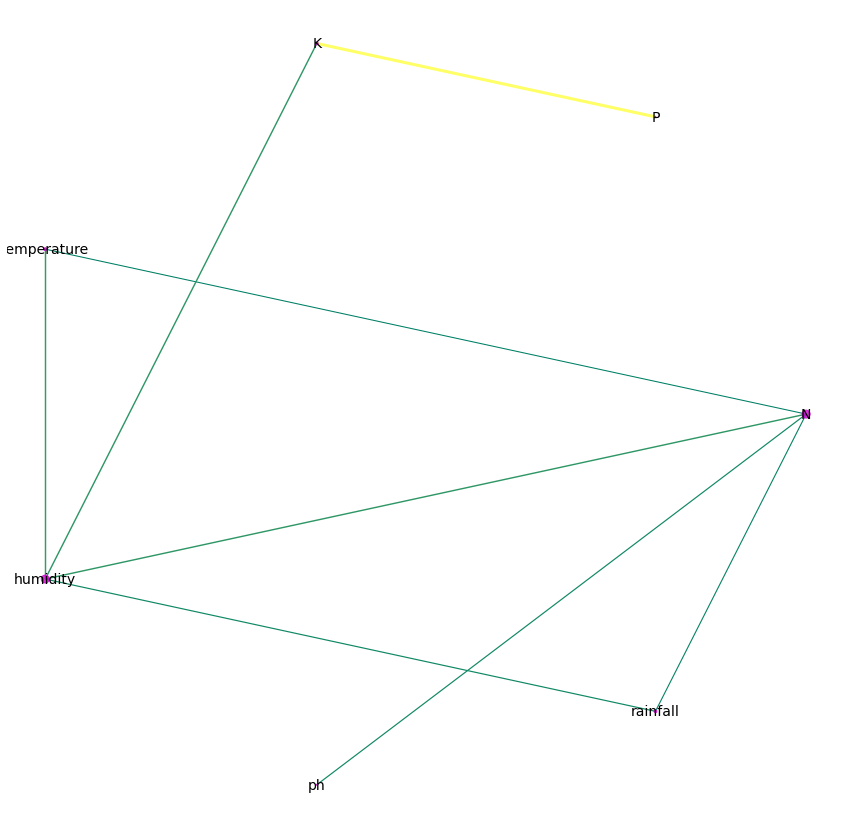

In [26]:
corr_network(G, corr_direction="positive",min_correlation =0)

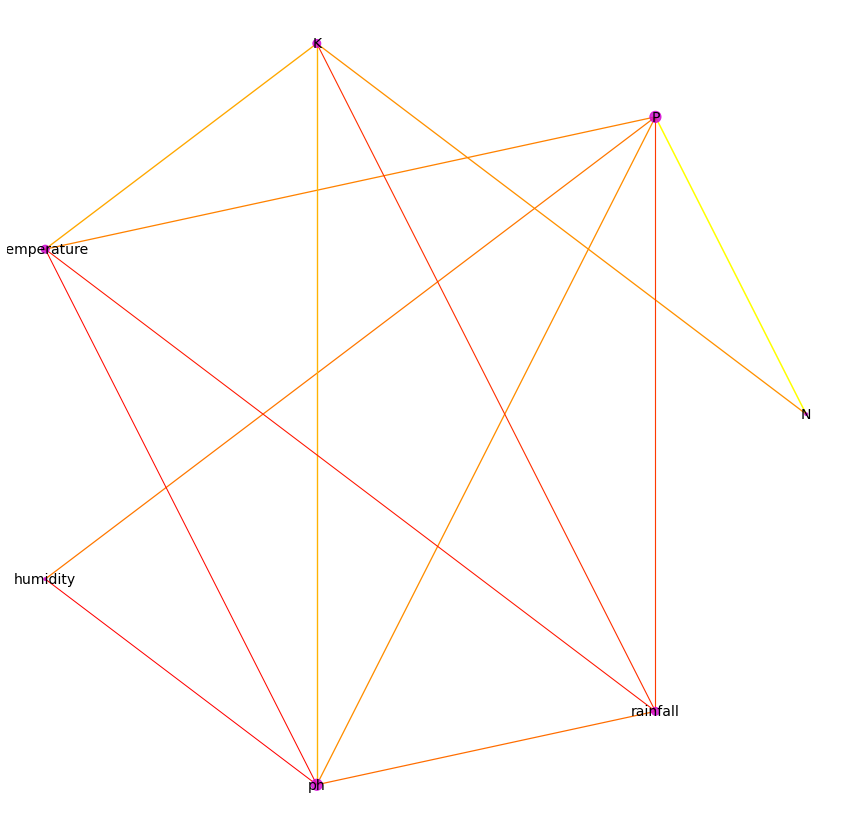

In [27]:
corr_network(G, corr_direction="negative",min_correlation = 0)

In [28]:
numeric=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_num=df.select_dtypes(include=numeric)
fig = make_subplots(rows=1, cols=len(df_num.columns))
featuresNum = df_num.columns

plt.figure(figsize=(50, 40))
for i in range(0, len(featuresNum)):
    trace=go.Box(y=df[featuresNum[i]], name=featuresNum[i])
    fig.append_trace(trace, row=1, col=i+1)

fig.show()

<Figure size 3600x2880 with 0 Axes>

In [29]:
numeric=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_num=df.select_dtypes(include=numeric)
featuresNum = ['N', 'P', 'K']

for i in range(-1, len(featuresNum)-3):
    fig = go.Figure()
    fig.update_layout(autosize=False, width=1280, height=720)
    trace1=go.Scatter(y=df[featuresNum[i+1]], name=featuresNum[i+1])
    fig.add_trace(trace1)
    trace2=go.Scatter(y=df[featuresNum[i+2]], name=featuresNum[i+2])
    fig.add_trace(trace2)
    trace3=go.Scatter(y=df[featuresNum[i+3]], name=featuresNum[i+3])
    fig.add_trace(trace3)
    fig.show()

In [30]:
numeric=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_num=df.select_dtypes(include=numeric)
featuresNum = df_num.columns

plt.figure(figsize=(50, 40))
for i in range(0, len(featuresNum)):
    fig = px.histogram(df, x=featuresNum[i])
    fig.show()

<Figure size 3600x2880 with 0 Axes>

In [31]:
featuresNum = df.columns

plt.figure(figsize=(50, 40))
for i in range(0, len(featuresNum)-1):
  fig = px.pie(df, values=featuresNum[i], names='label', color_discrete_sequence=px.colors.sequential.RdBu, title="Composition of crops with "+featuresNum[i])
  fig.show()

<Figure size 3600x2880 with 0 Axes>

In [32]:
fig = px.pie(df, values=df['label'].value_counts().values, names=df['label'].value_counts().index, color_discrete_sequence=px.colors.sequential.RdBu, title="Composition of crops class")
fig.show()

In [33]:
fig = px.scatter_matrix(df,
    dimensions=['N', 'P', 'K'],
    color="label")
fig.update_layout(autosize=True, width=1920, height=1080)
fig.show()

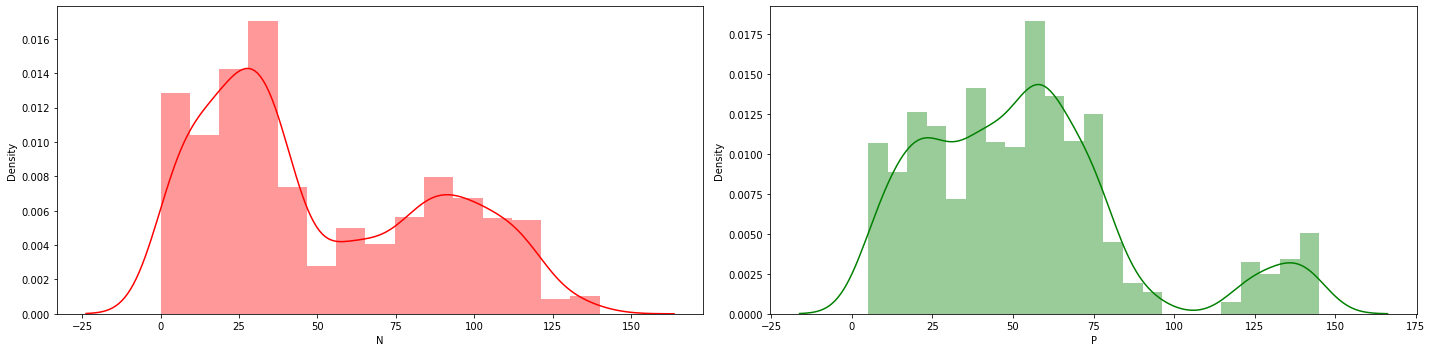

In [34]:
f= plt.figure(figsize=(20,5))
ax=f.add_subplot(121)
sns.distplot(df['N'] , color ='red',ax=ax)

ax=f.add_subplot(122)
sns.distplot(df['P'] , color ='green' , ax = ax)
plt.tight_layout()

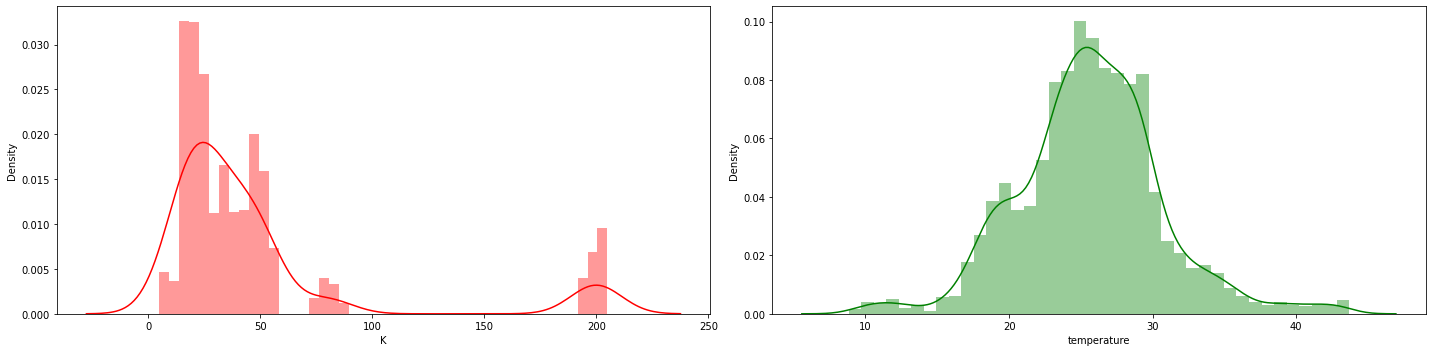

In [35]:
f= plt.figure(figsize=(20,5))
ax=f.add_subplot(121)
sns.distplot(df['K'] , color ='red',ax=ax)

ax=f.add_subplot(122)
sns.distplot(df['temperature'] , color ='green' , ax = ax)
plt.tight_layout()

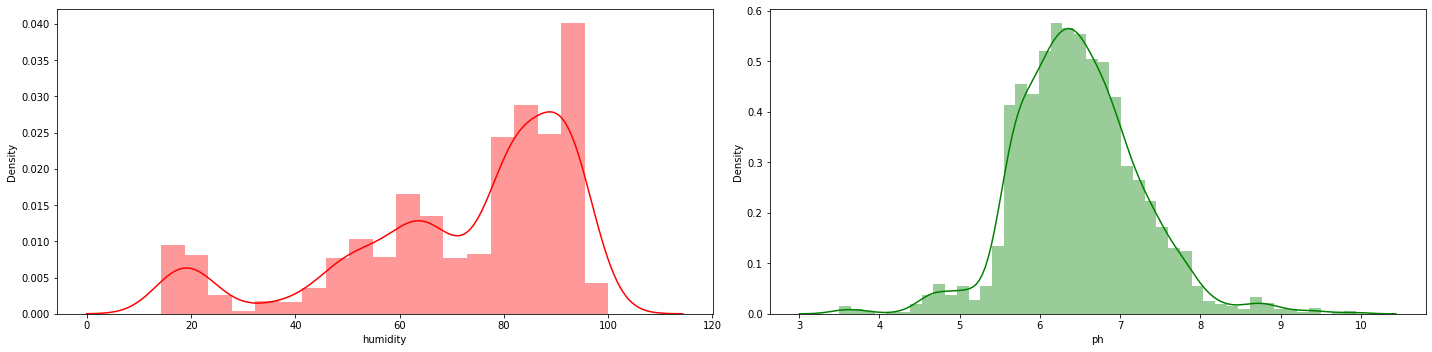

In [36]:
f= plt.figure(figsize=(20,5))
ax=f.add_subplot(121)
sns.distplot(df['humidity'] , color ='red',ax=ax)

ax=f.add_subplot(122)
sns.distplot(df['ph'] , color ='green' , ax = ax)
plt.tight_layout()

<AxesSubplot:xlabel='rainfall', ylabel='Density'>

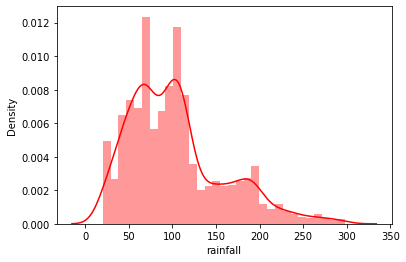

In [37]:
sns.distplot(df['rainfall'],color ='red')

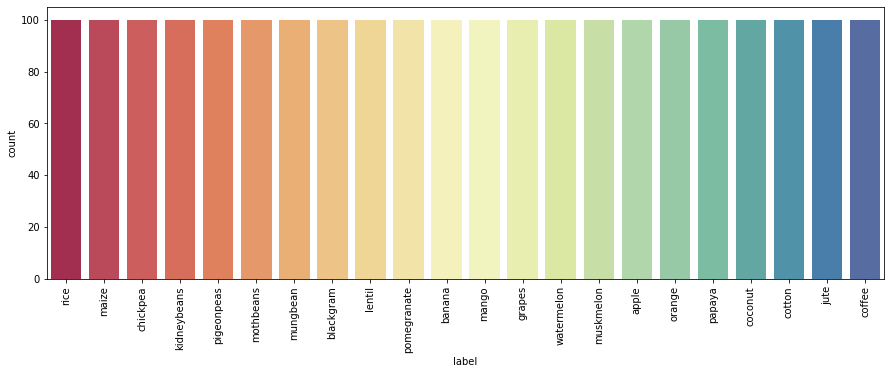

In [38]:
f= plt.figure(figsize=(15,5))
sns.countplot(df['label'] , palette = 'Spectral')
plt.xticks(rotation=90)
plt.show()

In [39]:
fig = px.scatter_matrix(df,
    dimensions=['temperature', 'humidity', 'rainfall',],
    color="label")
fig.update_layout(autosize=True, width=1920, height=1080)
fig.show()

In [40]:
fig = px.scatter_matrix(df,
    dimensions=['ph',],
    color="label")
fig.update_layout(autosize=True, width=1280, height=720)
fig.show()

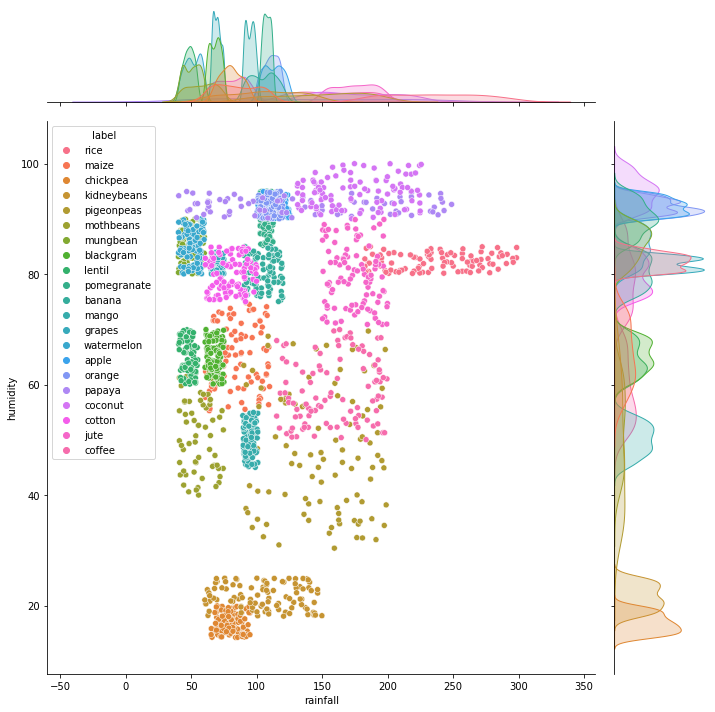

In [41]:
sns.jointplot(x="rainfall",y="humidity",data=df[(df['temperature']<40) & 
                                                  (df['rainfall']>40)],height=10,hue="label")

In [42]:
from sklearn import preprocessing
from plotly.subplots import make_subplots
from sklearn.metrics import classification_report
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.naive_bayes import GaussianNB  
from sklearn.model_selection import train_test_split

In [43]:
#Data Pre-Processing
label_encoder = preprocessing.LabelEncoder()
df['label']= label_encoder.fit_transform(df['label'])

df['label'].unique()

array([20, 11,  3,  9, 18, 13, 14,  2, 10, 19,  1, 12,  7, 21, 15,  0, 16,
       17,  4,  6,  8,  5])

In [44]:
features = df.columns[:-1]
X = df[features] # her we are droping the output feature as this is the target and 'X' is input features, the changes are not 
                                # made inplace as we have not used 'inplace = True'
y = df['label']

In [45]:
X_train, X_val_, y_train, y_val_ = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [46]:
X_val, X_test, y_val, y_test = train_test_split(X_val_, y_val_, test_size = 0.5, random_state = 42)

In [47]:
print("Shape of the X Train :", X_train.shape)
print("Shape of the y Train :", y_train.shape)
print("Shape of the X val :", X_val.shape)
print("Shape of the y val :", y_val.shape)
print("Shape of the X test :", X_test.shape)
print("Shape of the y test :", y_test.shape)

Shape of the X Train : (1540, 7)
Shape of the y Train : (1540,)
Shape of the X val : (330, 7)
Shape of the y val : (330,)
Shape of the X test : (330, 7)
Shape of the y test : (330,)


In [48]:
import plotly.express as px
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.figure_factory as ff
from matplotlib import pyplot

Importance of N is 634.109614
Importance of P is 1370.832913
Importance of K is 19278.607456
Importance of temperature is 65.061410
Importance of humidity is 2255.437627
Importance of ph is 47.624288
Importance of rainfall is 478.509208


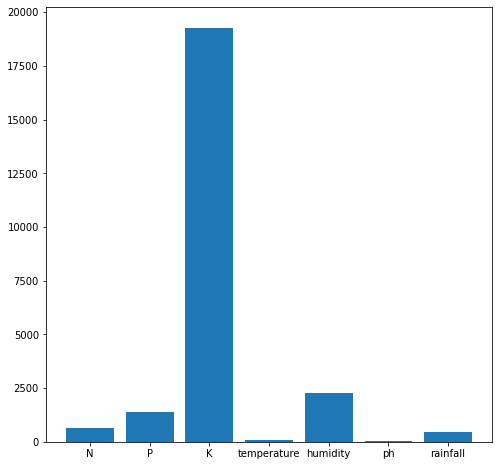

In [49]:
fs = SelectKBest(score_func=f_classif, k='all')
fs.fit(X_train, y_train)
feature_names=X.columns
for i in range(len(fs.scores_)):
	print('Importance of ' +feature_names[i]+' is %f' % (fs.scores_[i]))
# plot the scores
plt.rcParams["figure.figsize"] = (8,8)
pyplot.bar([i for i in X.columns], fs.scores_)
pyplot.show()

In [50]:
!pip install lazypredict

In [51]:
from lazypredict.Supervised import LazyClassifier
from sklearn.naive_bayes import GaussianNB  
from sklearn.model_selection import train_test_split

In [52]:
#Modelling
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

models

100%|██████████| 29/29 [00:05<00:00,  4.87it/s]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,0.99,0.99,None,0.99,0.37
GaussianNB,0.99,0.99,None,0.99,0.02
QuadraticDiscriminantAnalysis,0.99,0.99,None,0.99,0.02
DecisionTreeClassifier,0.98,0.98,None,0.98,0.02
BaggingClassifier,0.98,0.98,None,0.98,0.09
ExtraTreesClassifier,0.98,0.98,None,0.98,0.28
XGBClassifier,0.98,0.98,None,0.98,1.05
LGBMClassifier,0.98,0.98,None,0.98,1.53
SVC,0.98,0.97,None,0.98,0.08


In [53]:
model = GaussianNB()

In [54]:
model.fit(X_train, y_train)  

GaussianNB()

In [55]:
y_pred_test= model.predict(X_test)  

In [56]:
print(classification_report(np.array(y_test), y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        21
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        15
           6       1.00      1.00      1.00        13
           7       1.00      1.00      1.00        12
           8       0.89      1.00      0.94        17
           9       1.00      1.00      1.00        22
          10       1.00      1.00      1.00        11
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        21
          13       1.00      1.00      1.00        14
          14       1.00      1.00      1.00        14
          15       1.00      1.00      1.00        11
          16       1.00      1.00      1.00        12
          17       1.00    

In [57]:
X = df.drop('label' ,axis =1)
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.88,82.00,6.50,202.94
1,85,58,41,21.77,80.32,7.04,226.66
2,60,55,44,23.00,82.32,7.84,263.96
3,74,35,40,26.49,80.16,6.98,242.86
4,78,42,42,20.13,81.60,7.63,262.72


In [58]:
from sklearn.preprocessing import LabelEncoder

In [59]:
le = LabelEncoder()

In [60]:
df['label'] = le.fit_transform(df['label'])
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.88,82.00,6.50,202.94,20
1,85,58,41,21.77,80.32,7.04,226.66,20
2,60,55,44,23.00,82.32,7.84,263.96,20
3,74,35,40,26.49,80.16,6.98,242.86,20
4,78,42,42,20.13,81.60,7.63,262.72,20


In [61]:
y = df['label']
y.head()

0    20
1    20
2    20
3    20
4    20
Name: label, dtype: int64

In [62]:
model = []
accuracy = []

In [63]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [64]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(X_train , y_train)

DecisionTreeClassifier()

In [65]:
predict = DT.predict(X_test)

In [66]:
DT_accuracy = DT.score(X_test,y_test)

In [67]:
DT_accuracy

0.9818181818181818

In [68]:
accuracy.append(DT_accuracy)

In [69]:
model.append('Decision Tree')

In [70]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
LG = LogisticRegression()
LG.fit(X_train , y_train)

LogisticRegression()

In [71]:
LG_accuracy = LG.score(X_test,y_test)
LG_accuracy

0.9454545454545454

In [72]:
accuracy.append(LG_accuracy)

In [73]:
model.append('Logistic Regression')

In [74]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier()
RF.fit(X_train , y_train)

RandomForestClassifier()

In [75]:
RF_accuracy = RF.score(X_test,y_test)
RF_accuracy

0.9931818181818182

In [76]:
accuracy.append(RF_accuracy)
model.append('Random Forest')

In [77]:
model

['Decision Tree', 'Logistic Regression', 'Random Forest']

In [78]:
accuracy

[0.9818181818181818, 0.9454545454545454, 0.9931818181818182]

<AxesSubplot:>

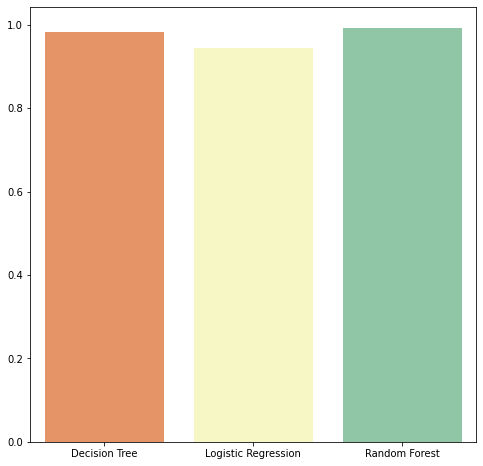

In [79]:
sns.barplot(x = model , y = accuracy ,palette ='Spectral')

<AxesSubplot:>

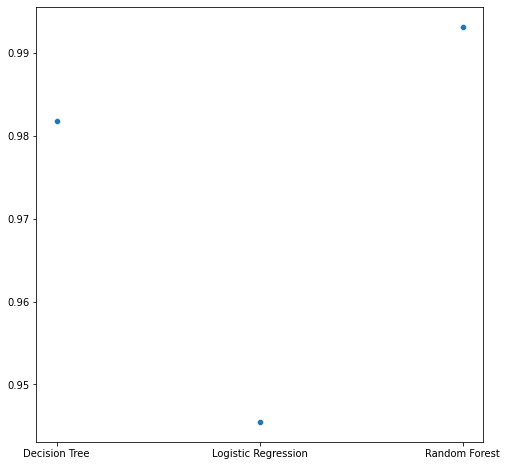

In [80]:
sns.scatterplot(x = model , y = accuracy ,palette ='Spectral')

<AxesSubplot:>

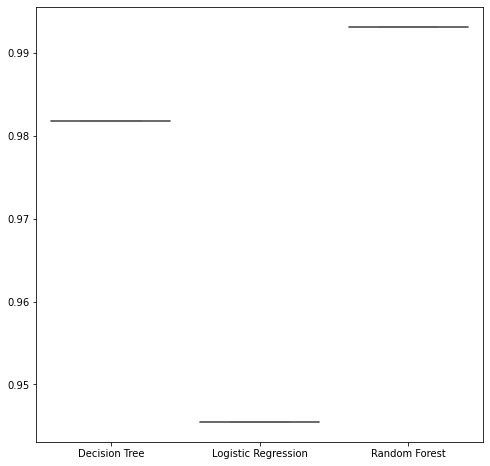

In [81]:
sns.boxplot(x = model , y = accuracy ,palette ='Spectral')

<Figure size 1368x1224 with 0 Axes>

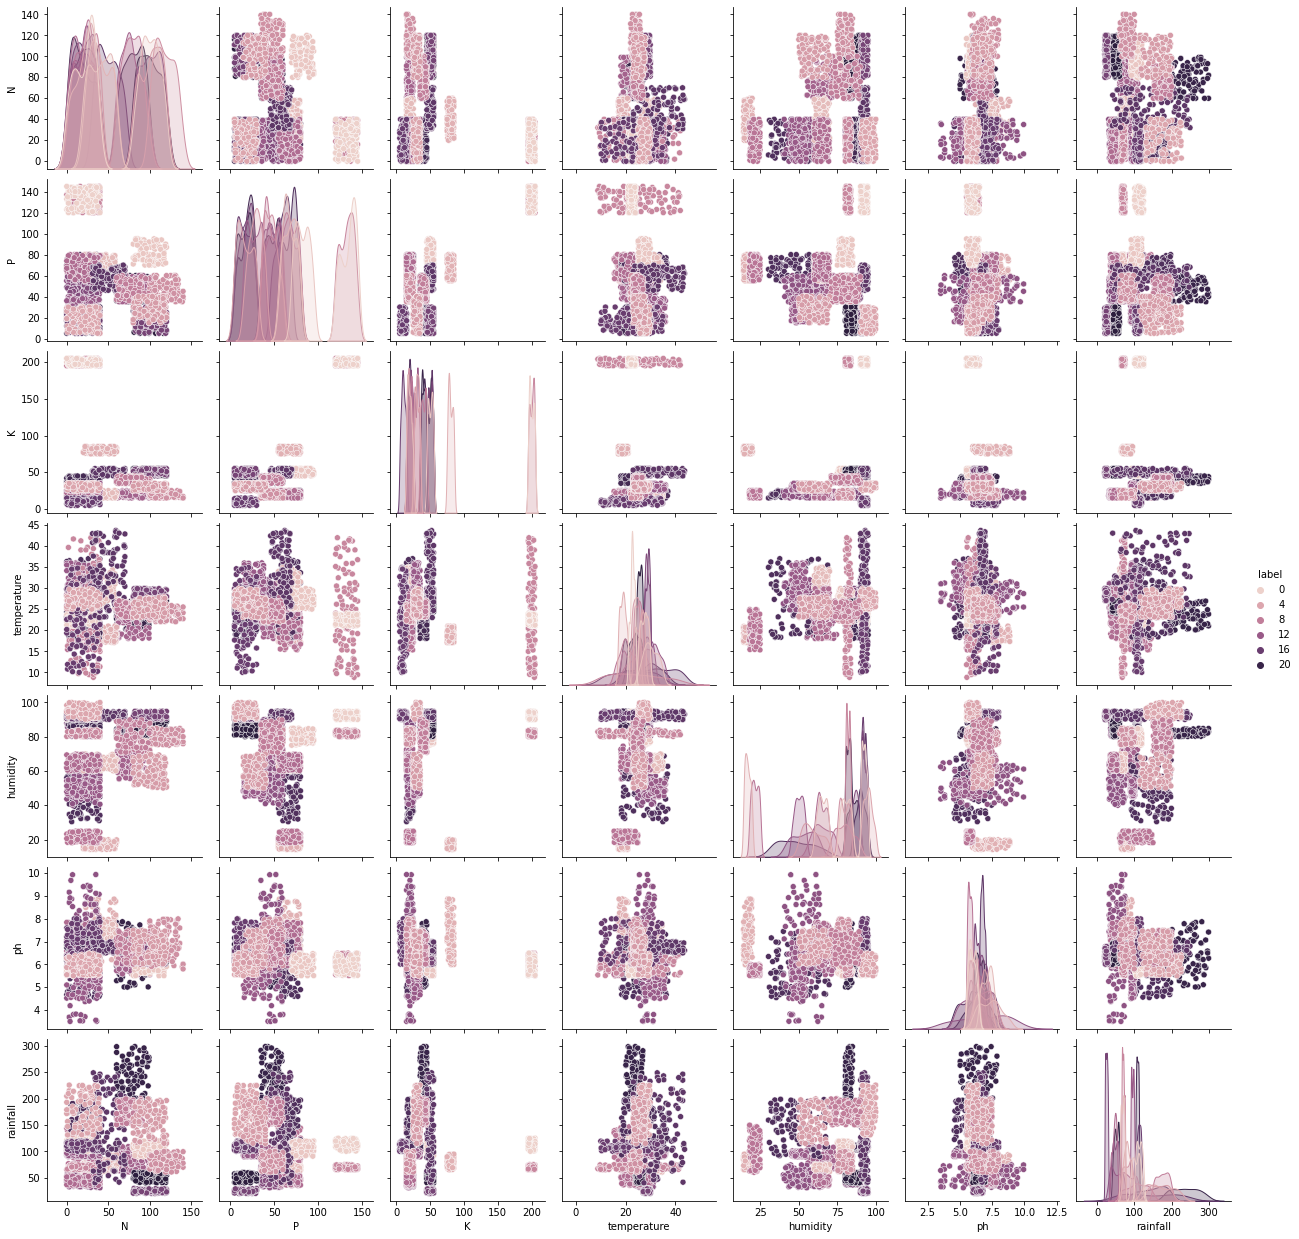

In [82]:
plt.figure(figsize=(19,17))
sns.pairplot(df, hue = "label")
plt.show()

**THANK YOU**